In [ ]:
import math
import numpy as np
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.pyplot import MultipleLocator
import scipy.optimize as so

#6.DBSCAN获得轮廓
def avedist_eps(bpoints):    #eps（相邻点之间的平均值）
    bpoints=sorted(bpoints,key=lambda x:x[0])      #bpoints按x由小到大排
    bpoints=np.array(bpoints) 
    a=len(bpoints)
    return sum((i**2 + j**2)**0.5/a for i, j in ((bpoints[k][0] - bpoints[k + 1][0], \
                                                  bpoints[k][1] - bpoints[k + 1][1]) for k in range(a - 1)))

def kdist_eps(bpoints,k):      #k-distance选出eps
    k_dist = []
    for i in range(bpoints.shape[0]):
        dist = (((bpoints[i] - bpoints)**2).sum(axis=1)**0.5)
        dist.sort()
        k_dist.append(dist[k])
    k_dist.sort()
    #plt.plot(np.arange(len(k_dist)),k_dist[::-1])
    for i in range(len(k_dist)-2,-1,-1):
        if k_dist[i+1]-k_dist[i]<=0.1:
            eps=k_dist[i]
            break
    #plt.show()        
    return eps
def dbscan_outline(r,bpoints,eps):       # 找到离群点
    db = DBSCAN(eps, min_samples=3).fit(bpoints)
    labels = db.labels_  # Number of clusters in labels, ignoring noise if present.
    dbpts=np.vstack((bpoints[:,0],bpoints[:,1],labels)).T
    label=np.unique(labels)
    times=[]
    for i in label:
        t=list(labels).count(i)
        times.append(t)
    index1,index2=pd.Series(times).sort_values(ascending = False).index[:2]
    a,b=label[index1],label[index2]         #选出label中出现最多的类别点拟合
    dbpt=[]
    for i in range(dbpts.shape[0]):
        if dbpts[i,2]==a or dbpts[i,2]==b:
            dbpt.append([dbpts[i,0],dbpts[i,1]])
    dbpt=np.array(dbpt)
    plt.figure(figsize=(4,2))
    plt.xlim(-2.5*r,2.5*r)
    plt.ylim(10,2.5*r-10)
    plt.scatter(bpoints[:,0],bpoints[:,1],c=labels,s=75,alpha=0.5,marker='o')
    plt.title('dbascan_outline')
    plt.show()
    return dbpt

eps=kdist_eps(bpoints,k=1)
bpoints=dbscan_outline(r,bpoints,eps)

(621, 3)
[  0   1   6   7  13  14  36 162 177]
      name          Ar         VE        EN           BP    Co    Re  class_2
0       Mg   24.310000   2.000000  1.310000  1363.000000  1.47  8.80        0
1       Al   26.981538   3.000000  1.610000  2792.000000  3.43  5.01        0
6       Zn   65.380000  12.000000  1.650000  1180.000000  1.34  8.10        0
7       Nb   92.906370   5.000000  1.600000  5017.000000  7.56  3.91        1
13      In  114.818000   3.000000  1.780000  2345.000000  2.48  7.18        0
14       W  183.840000   6.000000  2.360000  5828.000000  8.84  8.20        0
36   Al3Sc  125.900615   3.000000  1.520731  2903.050418  4.30  4.90        0
162   Cu9W  755.754000   9.783731  2.011897  3563.058495  4.75  4.89        0
177    CoK   98.031494   5.809327  1.457236  2335.327730  2.73  6.91        0


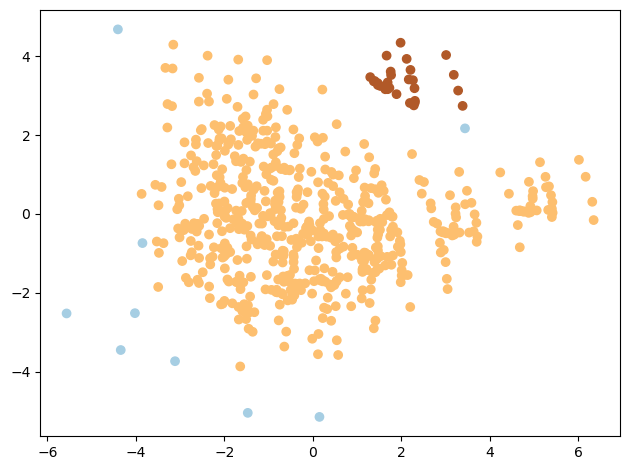

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster
from sklearn import datasets
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import pandas as pd
import math
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

df = pd.read_csv("class_2-4.csv")
X = df[['Ar', 'VE', 'EN', 'BP', 'Co']].to_numpy()
y = df.iloc[:, -1].to_numpy()

X=np.vstack((X[:,0]/100,X[:,1],X[:,2],X[:,3]/950,X[:,4])).T  # 对部分特征进行放缩
pca = PCA(n_components=3)
pca.fit(X)
reduced_x=pca.fit_transform(X)
print(reduced_x.shape)
# ----------对样本进行聚类----------------------
clf = cluster.DBSCAN(eps = 1.2, min_samples = 12)  # 初始化DBSCAN聚类模型
y_pred = clf.fit_predict(reduced_x)                        # 对样本进行聚类
# 获取噪声点的索引（DBSCAN 中噪声点标签为 -1）
noise_indices = np.where(y_pred == -1)[0]
row_indices = noise_indices
print(row_indices)
subset = df.iloc[row_indices][['name','Ar', 'VE', 'EN', 'BP', 'Co','Re','class_2']]
print(subset)
plt.scatter(reduced_x[:, 0], reduced_x[:, 1], c=y_pred,cmap='Paired' )            # 绘画结果


#标注序号
# for i, idx in enumerate(row_indices):
#     plt.annotate(str(idx), 
#                 xy=(reduced_x[idx, 0], reduced_x[idx, 1]),
#                 xytext=(reduced_x[idx, 0]-0.1, reduced_x[idx, 1]),
#                 fontsize=9,
#                 ha='center',
#                 va='bottom',
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7),  # 添加背景框
#                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))


plt.tight_layout()
plt.savefig("dbscan.png",transparent=True)  
plt.show()


Z-score离群点数量: 28
Z-score离群点索引: [  0   1   6   7  13  14  15  36  53  54 160 177 189 197 217 603 604 605
 606 607 608 610 611 612 613 614 615 618]

=== Z-score离群点信息 ===
      name          Ar         VE        EN           BP    Co    Re  class_2
0       Mg   24.310000   2.000000  1.310000  1363.000000  1.47  8.80        0
1       Al   26.981538   3.000000  1.610000  2792.000000  3.43  5.01        0
6       Zn   65.380000  12.000000  1.650000  1180.000000  1.34  8.10        0
7       Nb   92.906370   5.000000  1.600000  5017.000000  7.56  3.91        1
13      In  114.818000   3.000000  1.780000  2345.000000  2.48  7.18        0
14       W  183.840000   6.000000  2.360000  5828.000000  8.84  8.20        0
15      Os  190.230000   8.000000  2.200000  5285.000000  8.18  4.33        1
36   Al3Sc  125.900615   3.000000  1.520731  2903.050418  4.30  4.90        0
53    CuCd  175.960000  11.638861  1.765839  1688.244317  1.78  7.22        0
54    CuIn  178.364000   5.850172  1.822753  2519.5

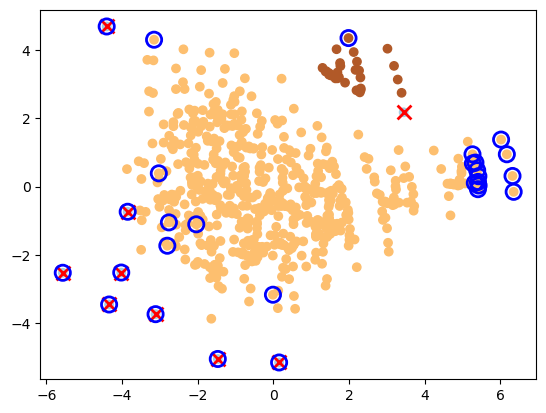

In [7]:
def detect_outliers_zscore(data, threshold=3):
    """使用Z-score方法检测离群点"""
    z_scores = np.abs(stats.zscore(data, axis=0))
    outlier_indices = np.where(np.any(z_scores > threshold, axis=1))[0]
    return outlier_indices

outliers_zscore = detect_outliers_zscore(reduced_x, threshold=2.5)
print(f"\nZ-score离群点数量: {len(outliers_zscore)}")
print(f"Z-score离群点索引: {outliers_zscore}")
print("\n=== Z-score离群点信息 ===")
if len(outliers_zscore) > 0:
    zscore_subset = df.iloc[outliers_zscore][['name','Ar', 'VE', 'EN', 'BP', 'Co','Re','class_2']]
    print(zscore_subset)


plt.scatter(reduced_x[:, 0], reduced_x[:, 1], c=y_pred,cmap='Paired' )            # 绘画结果
plt.scatter(reduced_x[noise_indices, 0], reduced_x[noise_indices, 1], 
               c='red', marker='x', s=100, label='噪声点', linewidths=2)
plt.scatter(reduced_x[outliers_zscore, 0], reduced_x[outliers_zscore, 1], 
               facecolors='none', edgecolors='blue', marker='o', s=120, 
               linewidths=2, label='Z-score离群点')


In [ ]:
db = DBSCAN(eps = 0.080, min_samples = 8).fit(m1)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print('Number of Clusters : ', n_clusters_)
print('Number of Outliers : ', n_noise_)          # 噪声点的数量

data['Class'] = labels; df1['Class'] = labels

(621, 3)
(621, 5)
[4.39592874 2.61756845 0.7836358  0.01377179 0.00779461]
[0.56223273 0.3347831  0.10022585 0.00176139 0.00099692]
0 0.000996919292956611
1 0.001761391946374447
2 0.10022585045513278
3 0.3347831035334944
4 0.5622327347720418


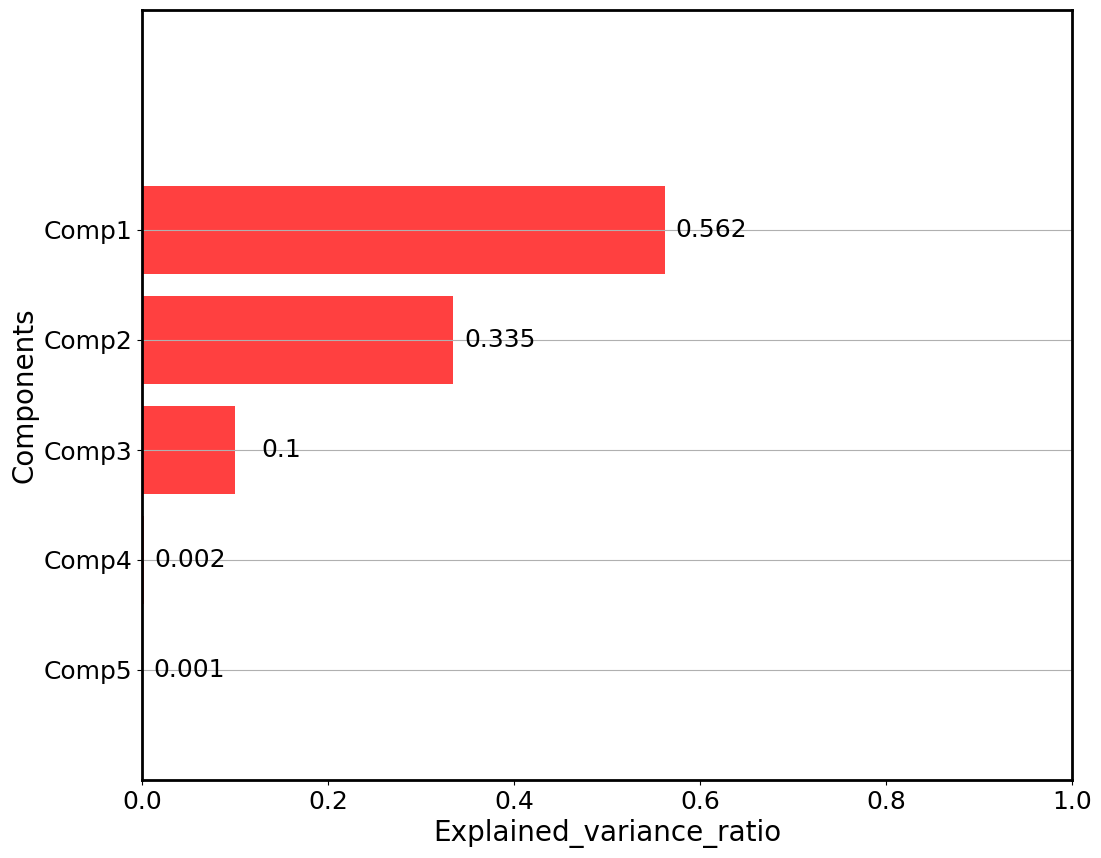

In [1]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)
print(X.shape)
print(X)
X = StandardScaler().fit_transform(X)

(750, 2)
[[ 0.84022039  1.14802236]
 [-1.15474834 -1.2041171 ]
 [ 0.67863613  0.72418009]
 ...
 [ 0.26798858 -1.27833405]
 [-0.88628813 -0.30293249]
 [ 0.60046048 -1.29605472]]
